# Day 1 — Learn Trading Basics

## 1. Stocks vs Crypto vs Forex

| Market | Description | Example |
|---|---|---|
| Stocks | Ownership in companies | Apple, Tesla |
| Crypto | Digital decentralized assets | Bitcoin, Ethereum |
| Forex | Currency exchange market | USD/INR |

### Key Differences

| Feature | Stocks | Crypto | Forex |
|---|---|---|---|
| Open Hours | Limited | 24/7 | 24/5 |
| Volatility | Medium | Very High | Medium |
| Regulation | High | Low-Medium | High |
| Liquidity | High | Medium-High | Very High |

---

## 2. Candlestick Charts

Each candle shows:

| Part | Meaning |
|---|---|
| Open | Starting price |
| High | Highest price |
| Low | Lowest price |
| Close | Ending price |

### OHLC Visualization

```text
  High
   |
 |----|
 |    |
Open  Close
 |    |
 |----|
   |
  Low
```

### Candle Types

- **Bullish Candle:** `Close > Open`
- **Bearish Candle:** `Close < Open`

---

## 3. OHLCV Data

OHLCV means:

| Column | Meaning |
|---|---|
| Open | Opening price |
| High | Highest price |
| Low | Lowest price |
| Close | Closing price |
| Volume | Number of trades |

This is the core data used in trading AI.

---

## 4. Market Trends

Three major market trends:

| Trend | Meaning |
|---|---|
| Uptrend | Higher highs |
| Downtrend | Lower lows |
| Sideways | No clear direction |

---

## 5. Volatility

**Volatility = speed of price movement**

### High Volatility
- Large price swings

### Low Volatility
- Stable prices

---

## 6. Support & Resistance

| Concept | Meaning |
|---|---|
| Support | Price floor |
| Resistance | Price ceiling |

### Example
Bitcoin repeatedly bounces at **$60,000** → support.

---

## 7. Liquidity

**Liquidity = ease of buying/selling without affecting price**

### High Liquidity
- Small spreads
- Faster execution

---

## 8. Market Microstructure

Studies:
- Order books
- Bid/Ask spread
- Trade execution
- Slippage

Important for **high-frequency trading (HFT)**.

---

# Why Prediction is Difficult

Markets are:
- Noisy
- Emotional
- Influenced by news
- Semi-random

## Efficient Market Hypothesis (EMH)

Public information is already reflected in price.

Therefore:

Finding alpha is difficult.


In [2]:
# pip install yfinance pandas matplotlib mplfinance

In [3]:
import yfinance as yf
import pandas as pd

# Download Apple stock data
data = yf.download("AAPL", start="2020-01-01")

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333862  72.394070  71.091169  71.344039  135480400
2020-01-03  71.630630  72.389250  71.406659  71.563198  146322800
2020-01-06  72.201416  72.239950  70.503554  70.754021  118387200
2020-01-07  71.861816  72.466299  71.642659  72.211018  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


In [4]:
print(data.columns)
print(data.info())


MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1601 entries, 2020-01-02 to 2026-05-15
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1601 non-null   float64
 1   (High, AAPL)    1601 non-null   float64
 2   (Low, AAPL)     1601 non-null   float64
 3   (Open, AAPL)    1601 non-null   float64
 4   (Volume, AAPL)  1601 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 75.0 KB
None


In [5]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [6]:
# Remove multi-level columns
data.columns = data.columns.get_level_values(0)

# Check columns
print(data.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [7]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data.dropna(inplace=True)

d:\Anaconda\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


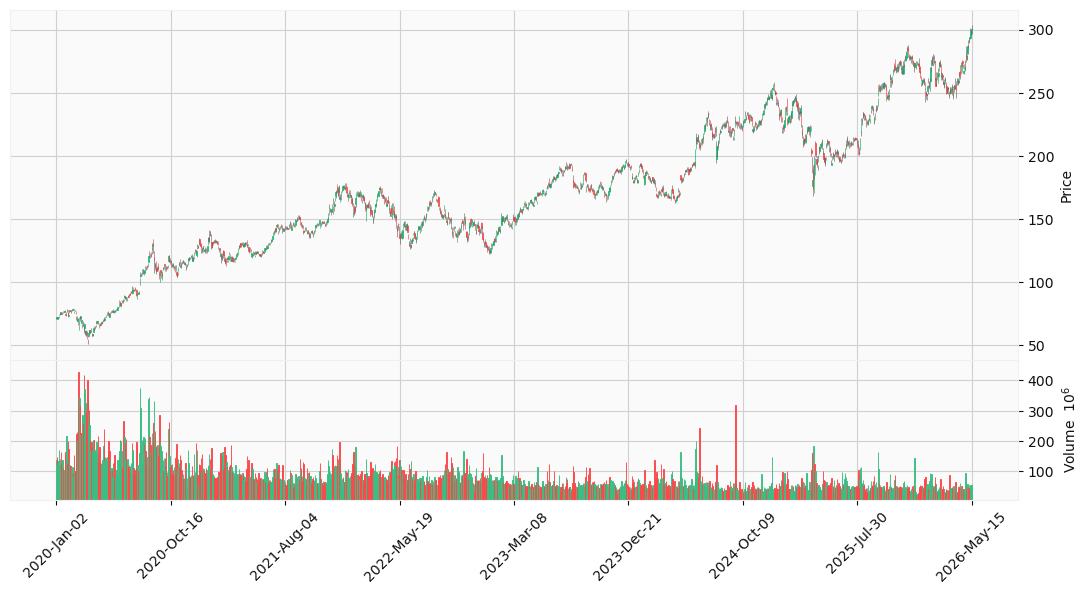

In [8]:
import mplfinance as mpf

mpf.plot(
    data,
    type='candle',
    volume=True,
    style='yahoo',
    figsize=(14,7)
)

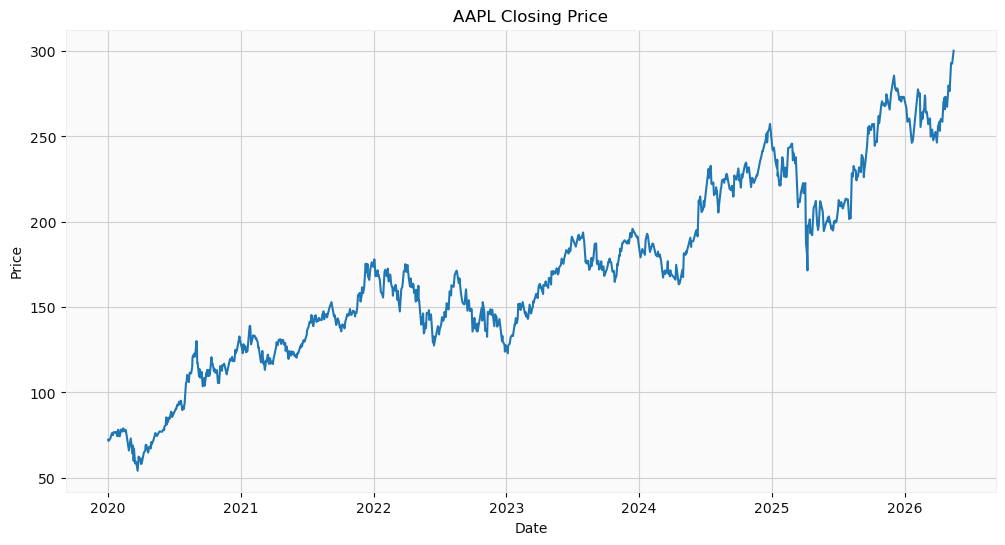

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

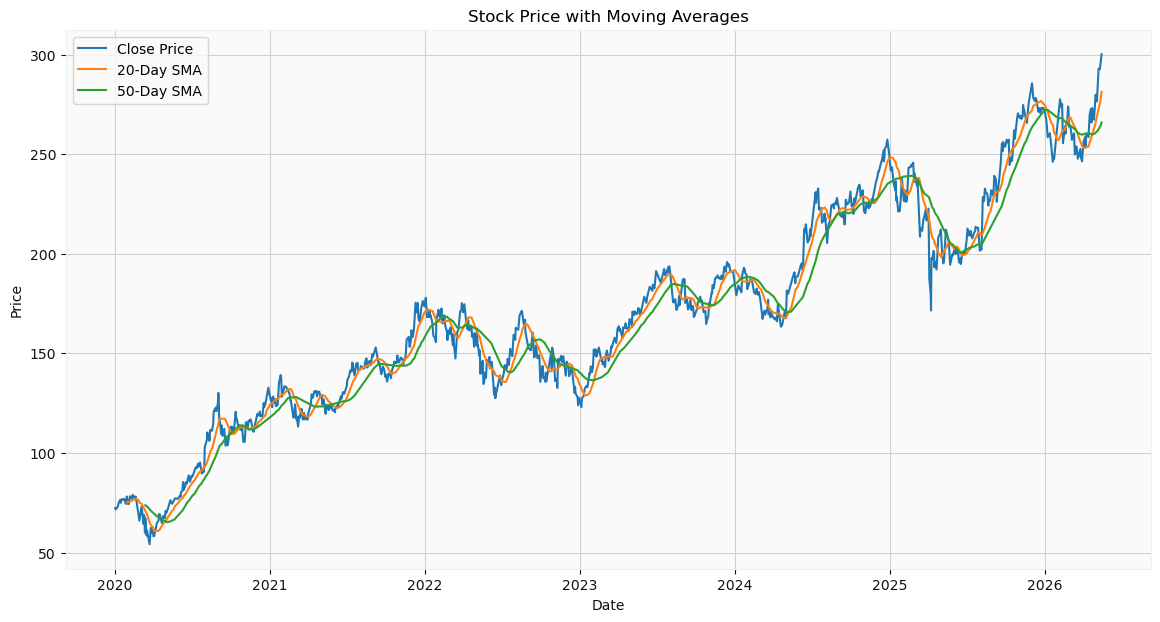

In [10]:
# Create Moving Averages
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()

plt.figure(figsize=(14,7))

plt.plot(data['Close'], label='Close Price')
plt.plot(data['SMA_20'], label='20-Day SMA')
plt.plot(data['SMA_50'], label='50-Day SMA')

plt.title("Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()


# Day 2 — Time Series Fundamentals

## What is Time Series Data?

Time series data is data indexed by time.

### Examples
- Stock prices
- Weather data
- Sensor readings

Trading AI depends heavily on **time-series analysis**.

---

# 1. Stationarity

A stationary series has:
- Constant mean
- Constant variance

ML models generally work better on stationary data.

### In Trading
- Stock prices are usually **non-stationary**
- Returns are more stationary

---

# 2. Rolling Windows

Rolling windows are used for:
- Moving averages
- Volatility estimation

### Example
- 20-day moving average

---

# 3. Lag Features

Past values used as features for prediction.

### Examples
- Yesterday's return
- Last week's volatility

Lag features help models learn patterns from historical data.

---

# 4. Moving Averages

## SMA (Simple Moving Average)

Formula:

\[
SMA_n = \frac{1}{n} \sum_{i=1}^{n} P_i
\]

Where:
- \( n \) = number of periods
- \( P_i \) = price at period \( i \)

### Purpose
- Smooths price fluctuations
- Identifies trend direction

---

## EMA (Exponential Moving Average)

EMA gives higher weight to recent prices.

### Characteristics
- Reacts faster to price changes
- Widely used in trading indicators

---

# 5. RSI (Relative Strength Index)

RSI measures momentum.

### Range
- 0 to 100

### Interpretation

| RSI Value | Meaning |
|---|---|
| RSI > 70 | Overbought |
| RSI < 30 | Oversold |

### Usage
Used to identify potential trend reversals.

---

# 6. MACD (Moving Average Convergence Divergence)

MACD is a trend-following indicator.

### Uses
- Fast EMA
- Slow EMA

### Purpose
- Detect momentum changes
- Identify buy/sell signals

---

# 7. Bollinger Bands

Bollinger Bands are bands around a moving average.

### Components
- Upper Band
- Lower Band

### Purpose
- Measure volatility
- Identify overbought/oversold conditions

### Interpretation
- Wide bands → high volatility
- Narrow bands → low volatility



In [11]:
data['SMA_20'] = data['Close'].rolling(20).mean()

In [12]:
data['EMA_20'] = data['Close'].ewm(span=20).mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7796\3639345412.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


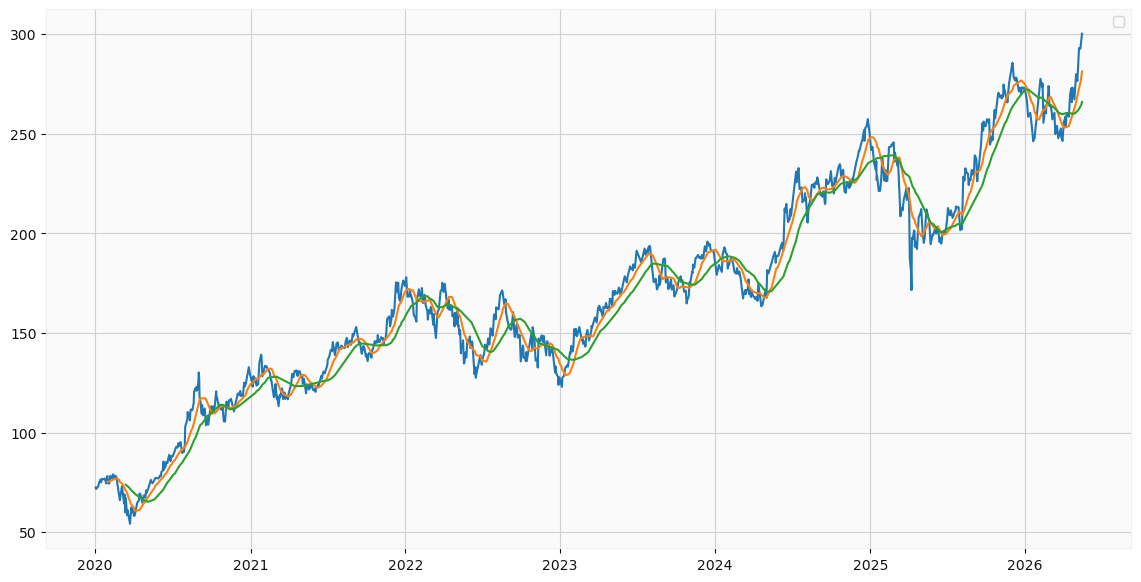

In [13]:
plt.figure(figsize=(14,7))
plt.plot(data['Close'])
plt.plot(data['SMA_20'])
plt.plot(data['SMA_50'])
plt.legend()

In [14]:
delta = data['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data['RSI'] = 100 - (100 / (1 + rs))

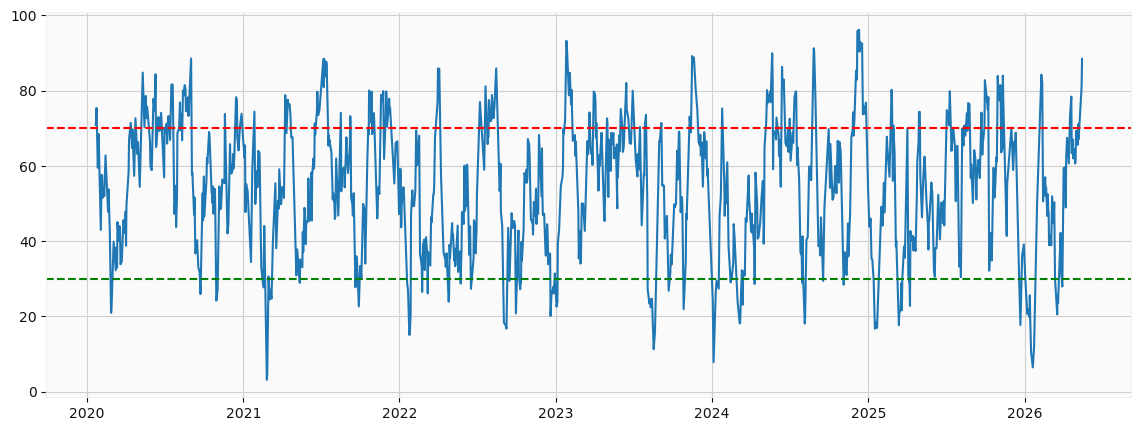

In [15]:
plt.figure(figsize=(14,5))
plt.plot(data['RSI'])
plt.axhline(70, color='r', linestyle='--')
plt.axhline(30, color='g', linestyle='--')

In [16]:
# MACD Calculation

exp1 = data['Close'].ewm(span=12, adjust=False).mean()
exp2 = data['Close'].ewm(span=26, adjust=False).mean()

# MACD Line
data['MACD'] = exp1 - exp2

# Signal Line
data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

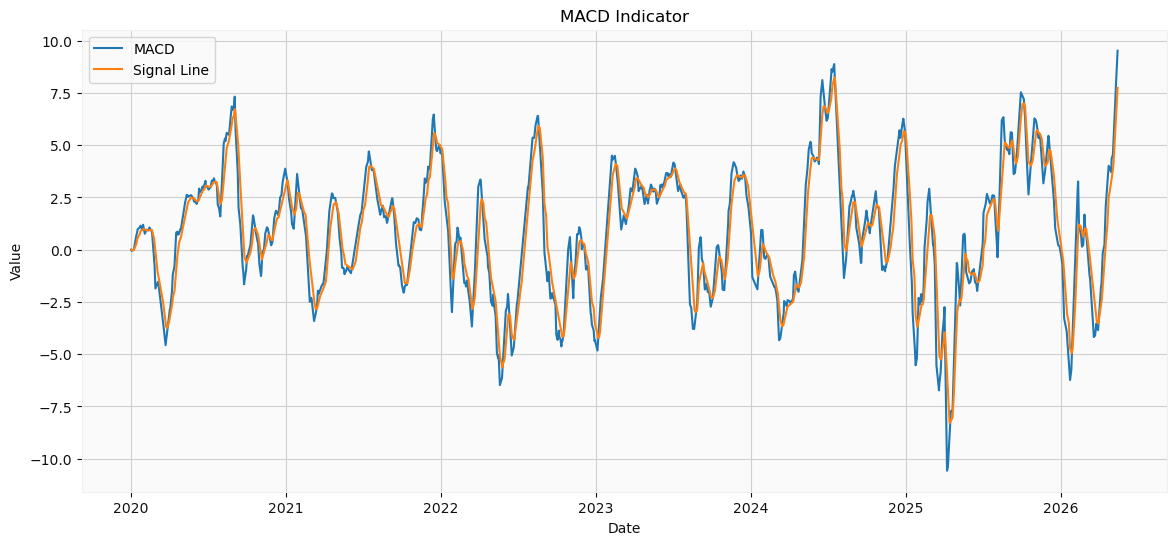

In [17]:
plt.figure(figsize=(14,6))

plt.plot(data['MACD'], label='MACD')
plt.plot(data['Signal_Line'], label='Signal Line')

plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.show()

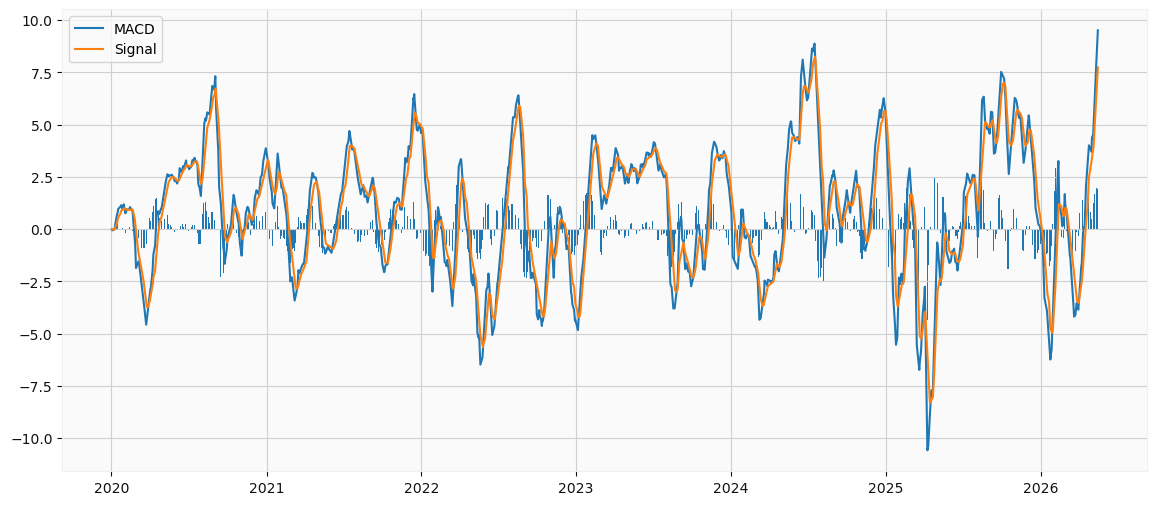

In [18]:
data['Histogram'] = data['MACD'] - data['Signal_Line']

plt.figure(figsize=(14,6))

plt.plot(data['MACD'], label='MACD')
plt.plot(data['Signal_Line'], label='Signal')

plt.bar(data.index, data['Histogram'])

plt.legend()
plt.show()

In [19]:
rolling_mean = data['Close'].rolling(20).mean()
rolling_std = data['Close'].rolling(20).std()

data['Upper_Band'] = rolling_mean + (2 * rolling_std)
data['Lower_Band'] = rolling_mean - (2 * rolling_std)

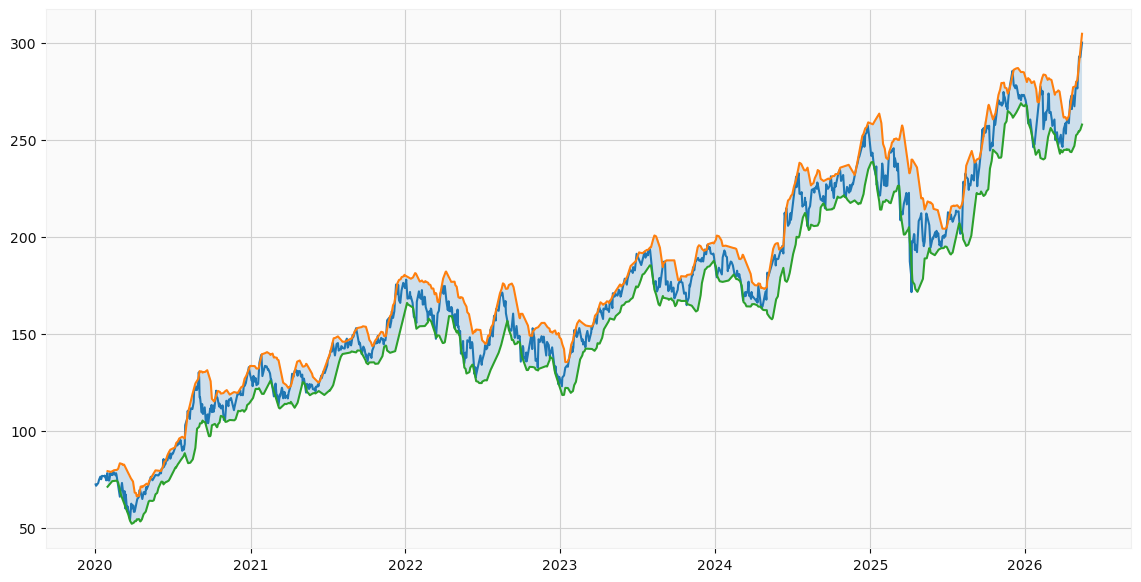

In [20]:
plt.figure(figsize=(14,7))
plt.plot(data['Close'])
plt.plot(data['Upper_Band'])
plt.plot(data['Lower_Band'])

plt.fill_between(
    data.index,
    data['Lower_Band'],
    data['Upper_Band'],
    alpha=0.2
)

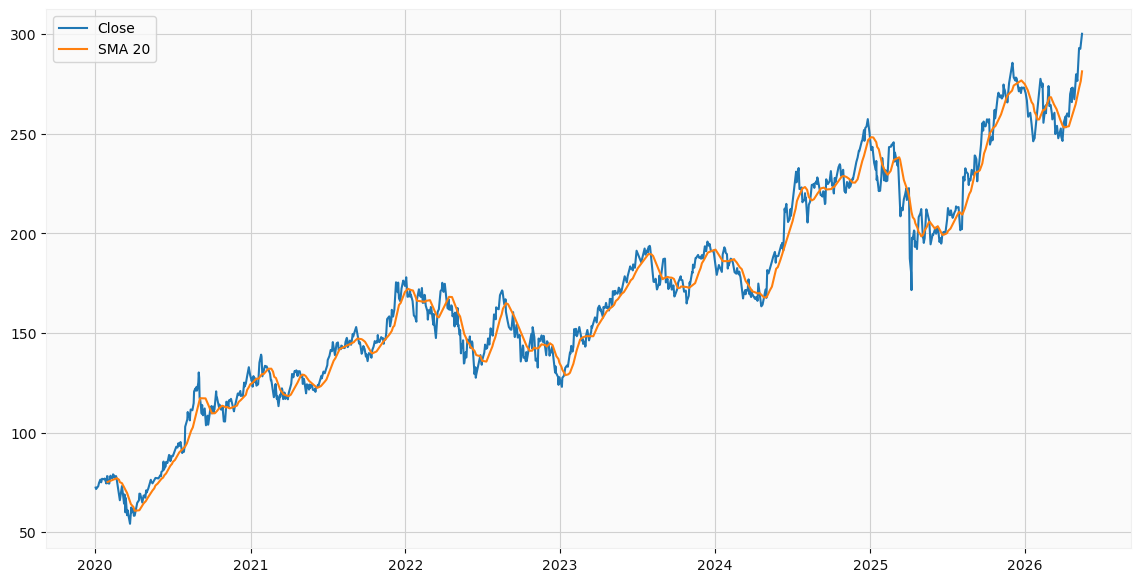

In [21]:
plt.figure(figsize=(14,7))

plt.plot(data['Close'], label='Close')
plt.plot(data['SMA_20'], label='SMA 20')

plt.legend()
plt.show()

# Day 3 — Feature Engineering

Feature engineering is the **MOST important** part of trading ML.

> Good features > complex models

---

# 1. Returns

Daily return formula:

\[
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
\]

Where:
- \( P_t \) = current price
- \( P_{t-1} \) = previous price

### Purpose
- Measures percentage price change
- Used heavily in trading models

---

# 2. Log Returns

Better for statistical modeling.

Formula:

\[
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
\]

### Advantages
- More mathematically stable
- Additive over time
- Common in quantitative finance

---

# 3. Volatility

Volatility = standard deviation of returns.

### Meaning
Measures how much prices fluctuate.

### Higher Volatility Means
- Higher risk
- Larger price swings

### Lower Volatility Means
- More stable market

---

# 4. Momentum

Momentum measures the speed of price movement.

### Example Formula

\[
Momentum = Price_{today} - Price_{10\ days\ ago}
\]

### Interpretation
- Positive momentum → upward trend
- Negative momentum → downward trend

Momentum is widely used in:
- Trend-following strategies
- Trading signals
- Quantitative models

---

# Why Feature Engineering Matters

Good features help ML models detect:
- Trends
- Volatility
- Momentum
- Market behavior

Even simple models can perform well with strong features.

In [22]:
data['Return'] = data['Close'].pct_change()

<Axes: >

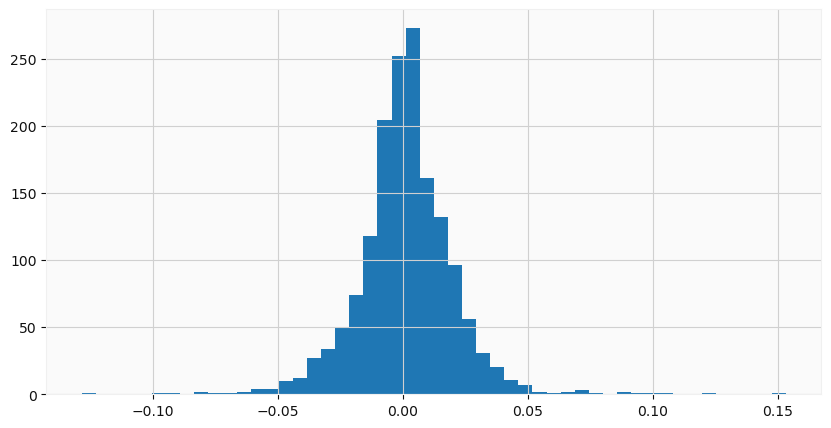

In [23]:
plt.figure(figsize=(10,5))
data['Return'].hist(bins=50)

In [24]:
import numpy as np

data['Log_Return'] = np.log(
    data['Close'] / data['Close'].shift(1)
)

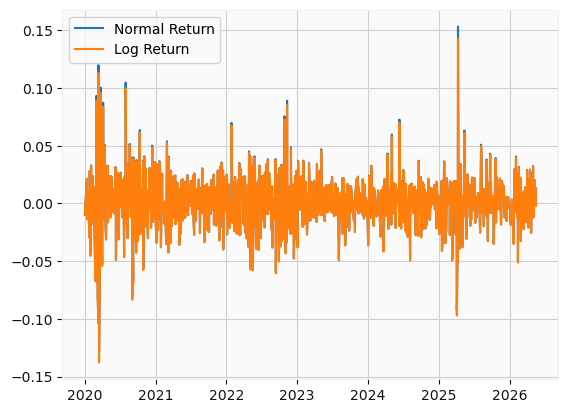

In [25]:
plt.plot(data['Return'], label='Normal Return')
plt.plot(data['Log_Return'], label='Log Return')
plt.legend()

In [26]:
data['Volatility'] = data['Return'].rolling(20).std()

Text(0.5, 1.0, '20-Day Rolling Volatility')

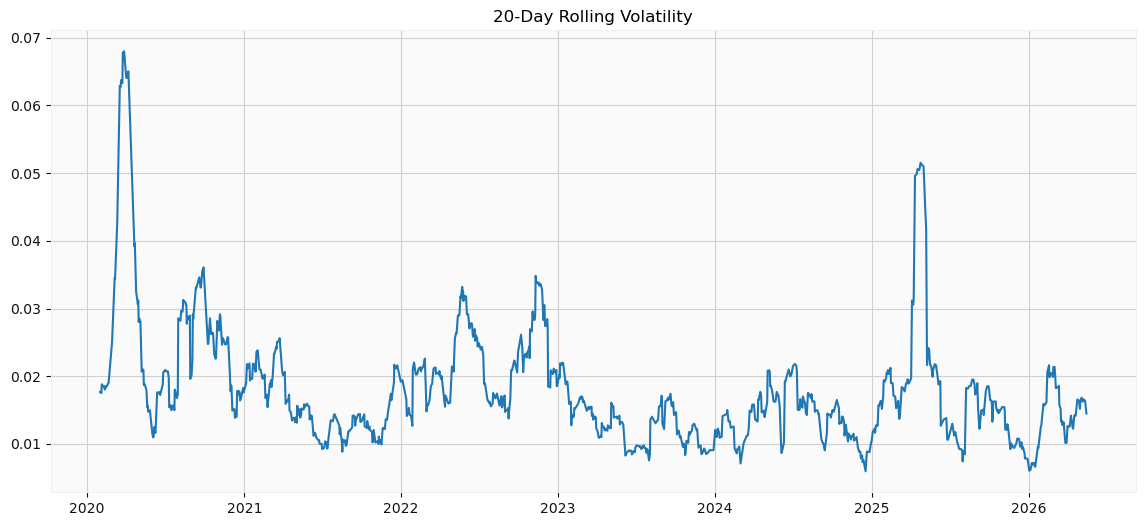

In [27]:
plt.figure(figsize=(14,6))
plt.plot(data['Volatility'])
plt.title("20-Day Rolling Volatility")

In [28]:
data['Momentum'] = data['Close'] - data['Close'].shift(10)

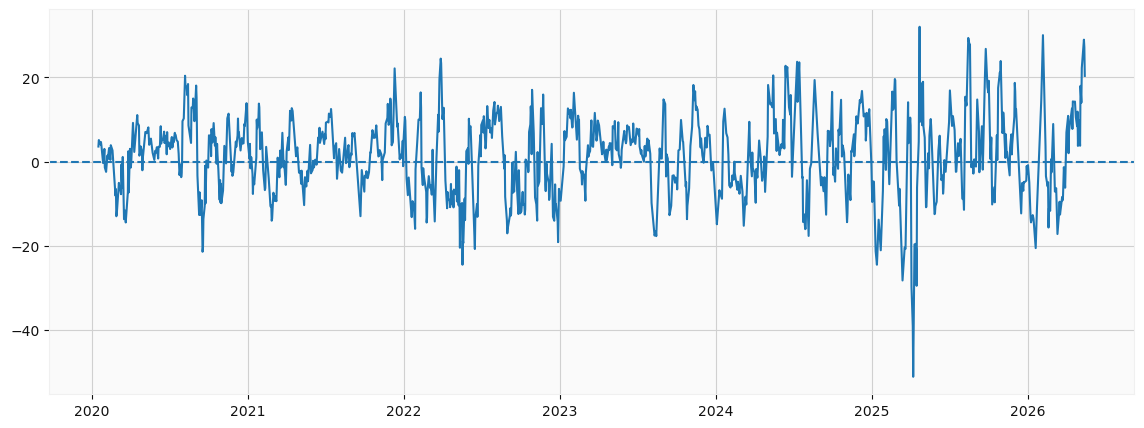

In [29]:
plt.figure(figsize=(14,5))
plt.plot(data['Momentum'])
plt.axhline(0, linestyle='--')

In [30]:
data['Volume_Change'] = data['Volume'].pct_change()

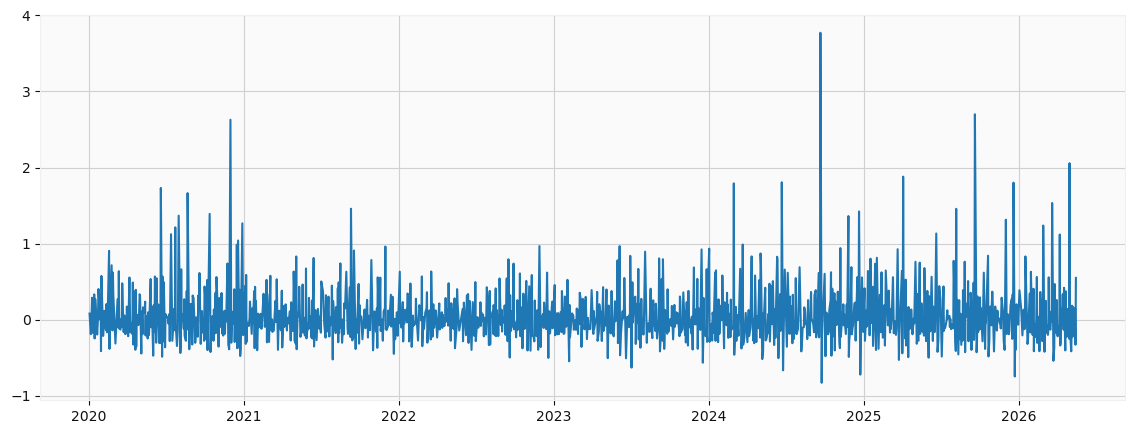

In [31]:
plt.figure(figsize=(14,5))
plt.plot(data['Volume_Change'])

In [32]:
for lag in range(1,6):
    data[f'lag_{lag}'] = data['Return'].shift(lag)

In [33]:

data['Target'] = data['Close'].shift(-1) / data['Close'] - 1

In [34]:
data.dropna(inplace=True)

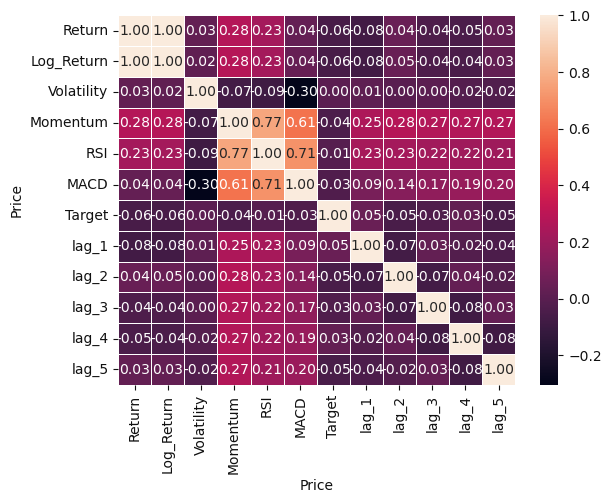

In [39]:
import seaborn as sns

features = [
    'Return',
    'Log_Return',
    'Volatility',
    'Momentum',
    'RSI',
    'MACD',
    'Target',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5'
]

sns.heatmap(data[features].corr(), annot=True, fmt=".2f", linewidths=0.5)
plt.grid(False)
plt.show()